# Indoor VPR experiment workbench

Change the dataset and algorithm in **Configuration**, then run all cells. Results stay in memory so you can inspect individual matches without recomputing descriptors.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from indoor_vpr import DatasetConfig, ImageDataset, create_algorithm, list_algorithms, run_vpr
from indoor_vpr.visualization import show_matches, show_similarity_matrix

print('Algorithms:', list_algorithms())

Algorithms: ['anyloc', 'dinov2', 'mixvpr', 'rgb_histogram']


## Configuration

This is the only cell you normally need to edit. Use `rgb_histogram` for a quick baseline or `dinov2`, `mixvpr`, and `anyloc` for learned descriptors. Set either limit to `None` to use every image.

In [2]:
# Dataset: change these two folders for a new experiment.
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'dataset-1'
DATABASE_DIR = DATASET_ROOT / 'frames-IMG_3597'
QUERY_DIR = DATASET_ROOT / 'frames-IMG_3598'
MAX_DATABASE_IMAGES = None
MAX_QUERY_IMAGES = None

# Algorithm: choose a name printed above and its constructor options.
ALGORITHM = 'mixvpr'  # Try: 'rgb_histogram', 'dinov2', 'mixvpr', or 'anyloc'
ALGORITHM_OPTIONS = {
    'rgb_histogram': {'bins': 32},
    'dinov2': {'model_name': 'dinov2_vitb14', 'batch_size': 16},
    'mixvpr': {'output_dim': 4096, 'batch_size': 8},
    'anyloc': {
        'model_name': 'dinov2_vitg14',
        'layer': 31,
        'facet': 'value',
        'num_clusters': 32,
        'vocabulary_path': None,
        'max_image_size': 1024,
    },
}
TOP_K = 5

## Load the selected dataset

In [3]:
dataset_config = DatasetConfig(
    database_dir=DATABASE_DIR,
    query_dir=QUERY_DIR,
    max_database_images=MAX_DATABASE_IMAGES,
    max_query_images=MAX_QUERY_IMAGES,
)
dataset = ImageDataset.from_config(dataset_config)
print(dataset.summary())

Database: 12 images | Queries: 27 images


## Run retrieval

In [4]:
algorithm = create_algorithm(ALGORITHM, **ALGORITHM_OPTIONS.get(ALGORITHM, {}))
print(f'Running {algorithm.name} ...')
results = run_vpr(dataset, algorithm)
print(f'Done: {results.similarity.shape[0]} queries × {results.similarity.shape[1]} database images')

Cached MixVPR checkpoint is incomplete; downloading it again: /Users/armin/.cache/torch/hub/checkpoints/resnet50_MixVPR_4096_channels(1024)_rows(4).ckpt


100.0%


Running mixvpr ...
Done: 27 queries × 12 database images


## Inspect the outputs

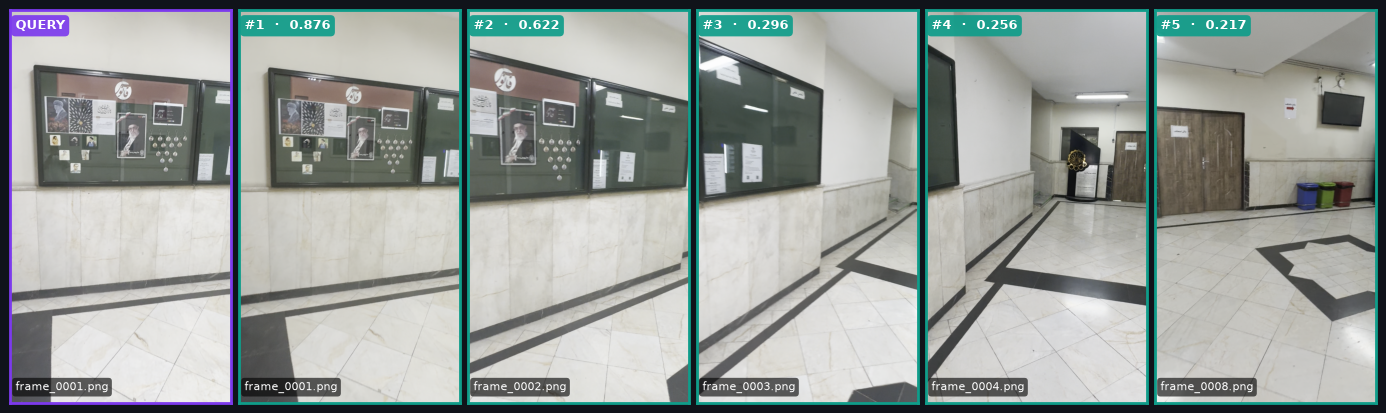

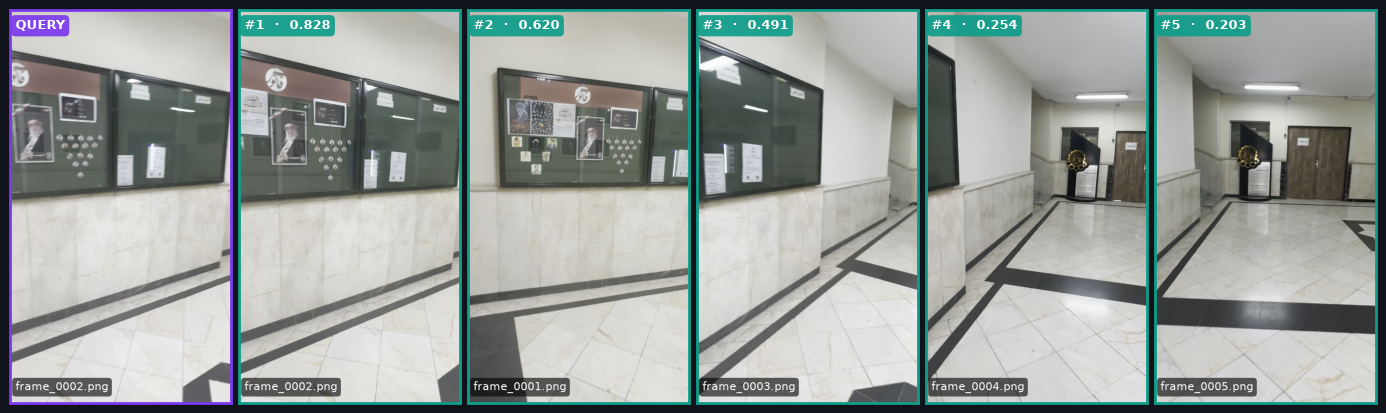

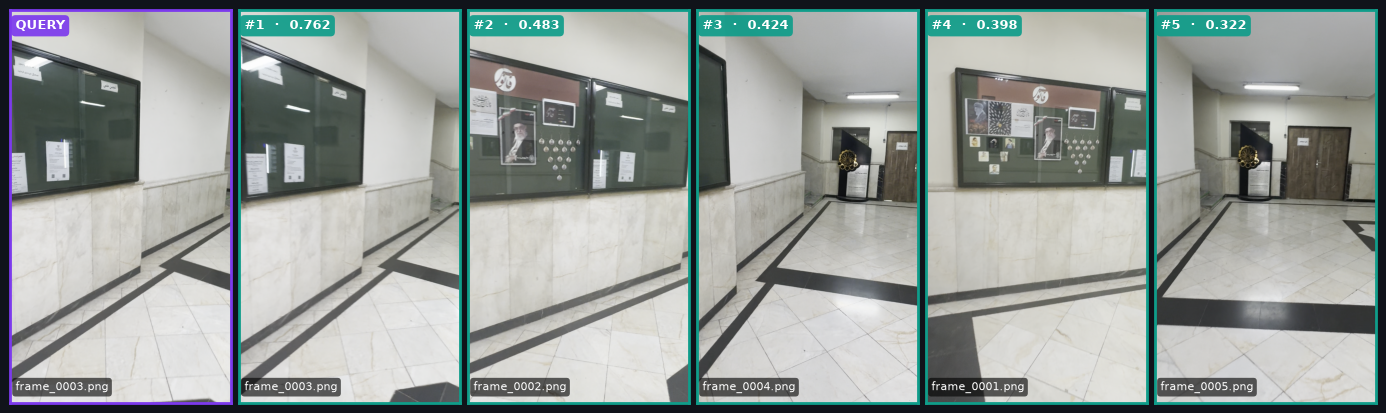

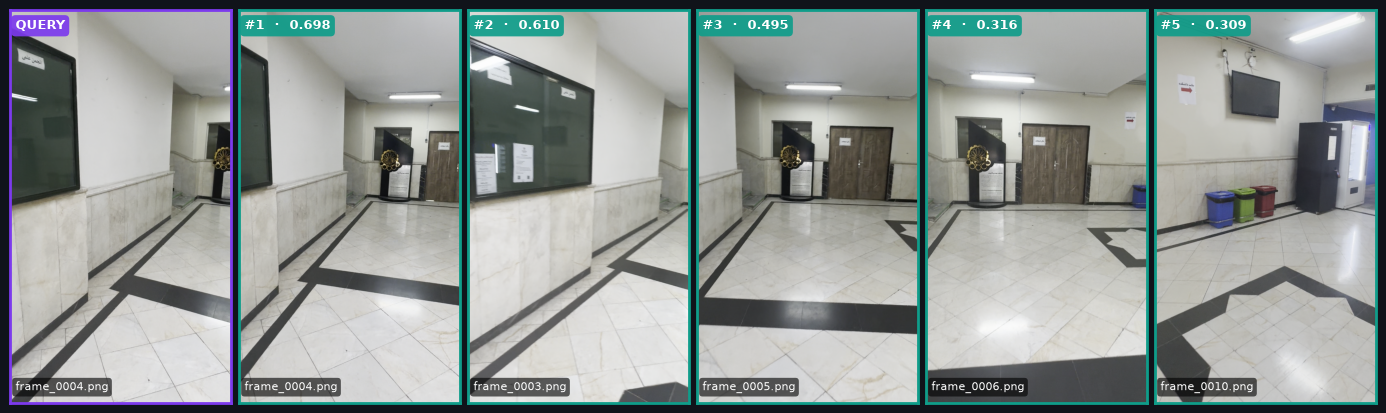

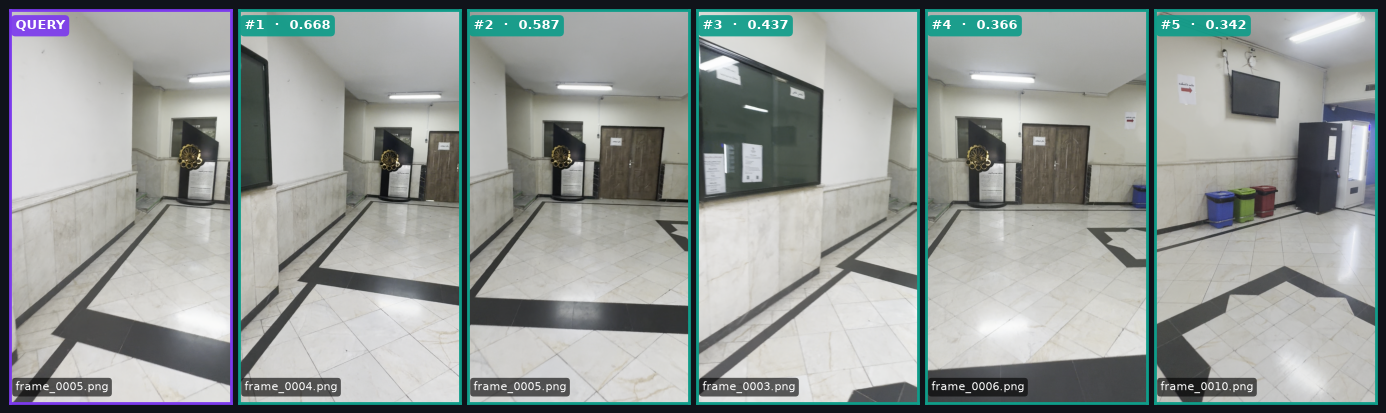

In [5]:
QUERY_INDEX = 5  # Change this to inspect another query.
for i in range(0, 5):
    show_matches(results, query_index=i, top_k=TOP_K);

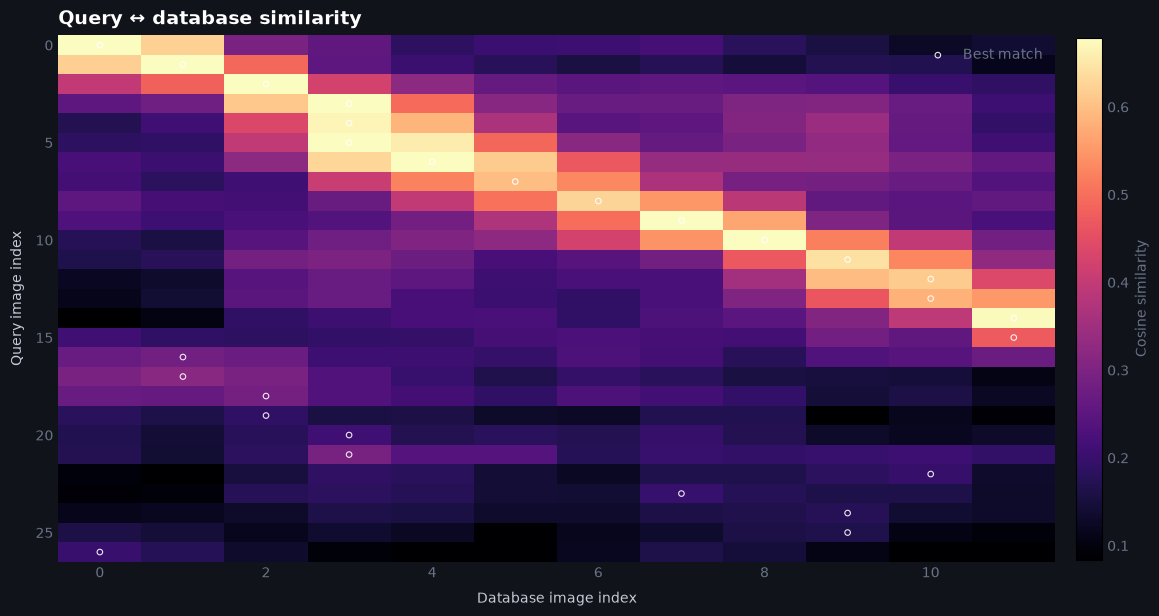

In [7]:
show_similarity_matrix(results);